# Citi Bike EDA + Leakage-Safe Feature Engineering (v2.0)

This notebook rebuilds the training dataset from raw trip files, with a corrected temporal pipeline to prevent leakage.

Key goals:
- Perform practical EDA for trip behavior and station demand.
- Build station-hour `net_demand` correctly using timestamp-aware aggregation.
- Engineer lag/rolling/time features using strictly past information.
- Add leakage checks before saving the final dataset.


## Why v1 leaked

In `EDA_v.1.0.ipynb`, aggregation and merge were done by `station + hour` only (without date/time key), which copied one yearly average-like value to every date.

Then `lag_24h` was computed on this repeated pattern, making it equal to `net_demand` for every row.

This version fixes that by preserving **`datetime_hour`** throughout aggregation and merging.


In [1]:
# Colab setup (same loading style as v1)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import gc
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)

# Keep same raw dataset location used in v1
DATASET_PATH = Path('/content/drive/My Drive/AIT/ML/citibike_project/dataset')
EXTRACTION_PATH = Path('/content/citibike_data')

# Save output into this project folder on Drive
PROJECT_ROOT = Path('/content/drive/My Drive/AIT/ML/citibike-netdemand-prediction')
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'proceed'
OUTPUT_FILE = OUTPUT_DIR / 'micro_mobility_training_data_2025_v2.csv'

EXTRACTION_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('DATASET_PATH :', DATASET_PATH)
print('EXTRACTION_PATH:', EXTRACTION_PATH)
print('OUTPUT_FILE  :', OUTPUT_FILE)


DATASET_PATH : /content/drive/My Drive/AIT/ML/citibike_project/dataset
EXTRACTION_PATH: /content/citibike_data
OUTPUT_FILE  : /content/drive/My Drive/AIT/ML/citibike-netdemand-prediction/data/proceed/micro_mobility_training_data_2025_v2.csv


In [3]:
# Extract zip files (raw monthly Citi Bike files)
zip_files = sorted(DATASET_PATH.glob('*.zip'))
print(f'Found {len(zip_files)} zip files')

for zp in zip_files:
    print(f'Extracting: {zp.name}')
    with zipfile.ZipFile(zp, 'r') as zf:
        zf.extractall(EXTRACTION_PATH)

csv_files = sorted(EXTRACTION_PATH.glob('*.csv'))
print(f'CSV files available after extraction: {len(csv_files)}')
print([f.name for f in csv_files[:6]])


Found 12 zip files
Extracting: JC-202501-citibike-tripdata.csv.zip
Extracting: JC-202502-citibike-tripdata.csv.zip
Extracting: JC-202503-citibike-tripdata.csv.zip
Extracting: JC-202504-citibike-tripdata.csv.zip
Extracting: JC-202505-citibike-tripdata.csv.zip
Extracting: JC-202506-citibike-tripdata.csv.zip
Extracting: JC-202507-citibike-tripdata.csv.zip
Extracting: JC-202508-citibike-tripdata.csv.zip
Extracting: JC-202509-citibike-tripdata.csv.zip
Extracting: JC-202510-citibike-tripdata.zip
Extracting: JC-202511-citibike-tripdata.csv.zip
Extracting: JC-202512-citibike-tripdata.csv.zip
CSV files available after extraction: 12
['JC-202501-citibike-tripdata.csv', 'JC-202502-citibike-tripdata.csv', 'JC-202503-citibike-tripdata.csv', 'JC-202504-citibike-tripdata.csv', 'JC-202505-citibike-tripdata.csv', 'JC-202506-citibike-tripdata.csv']


## Load and clean trip-level data

We keep only needed columns, parse timestamps, and remove anomalous trips.

Filtering logic:
- Convert `started_at`, `ended_at` to datetime.
- Keep trip duration in `[1, 1440]` minutes.
- Keep only trips with valid start/end stations and coordinates.


In [4]:
REQUIRED_COLS = [
    'ride_id', 'rideable_type', 'started_at', 'ended_at',
    'start_station_name', 'end_station_name',
    'start_lat', 'start_lng', 'end_lat', 'end_lng',
    'member_casual'
]

def load_trips(csv_paths):
    frames = []
    for path in csv_paths:
        df = pd.read_csv(path, usecols=lambda c: c in REQUIRED_COLS)
        df['source_file'] = path.name
        frames.append(df)
    if not frames:
        raise ValueError('No CSV files were loaded. Check DATASET_PATH and zip content.')
    return pd.concat(frames, ignore_index=True)

trips_raw = load_trips(csv_files)
print('Raw shape:', trips_raw.shape)

trips = trips_raw.copy()
trips['started_at'] = pd.to_datetime(trips['started_at'], errors='coerce')
trips['ended_at'] = pd.to_datetime(trips['ended_at'], errors='coerce')

trips = trips.dropna(subset=['started_at', 'ended_at'])
trips['duration_mins'] = (trips['ended_at'] - trips['started_at']).dt.total_seconds() / 60.0
trips = trips[(trips['duration_mins'] >= 1) & (trips['duration_mins'] <= 1440)].copy()

station_cols = ['start_station_name', 'end_station_name', 'start_lat', 'start_lng', 'end_lat', 'end_lng']
trips = trips.dropna(subset=station_cols).copy()

trips['datetime_hour'] = trips['started_at'].dt.floor('h')
trips['date'] = trips['datetime_hour'].dt.normalize()
trips['hour'] = trips['datetime_hour'].dt.hour.astype('int8')

print('Clean shape:', trips.shape)
print('Unique start stations:', trips['start_station_name'].nunique())
print('Date range:', trips['datetime_hour'].min(), 'to', trips['datetime_hour'].max())


Raw shape: (1002704, 12)
Clean shape: (998438, 16)
Unique start stations: 112
Date range: 2024-12-31 23:00:00 to 2025-12-31 23:00:00


## Quick EDA (trip-level)


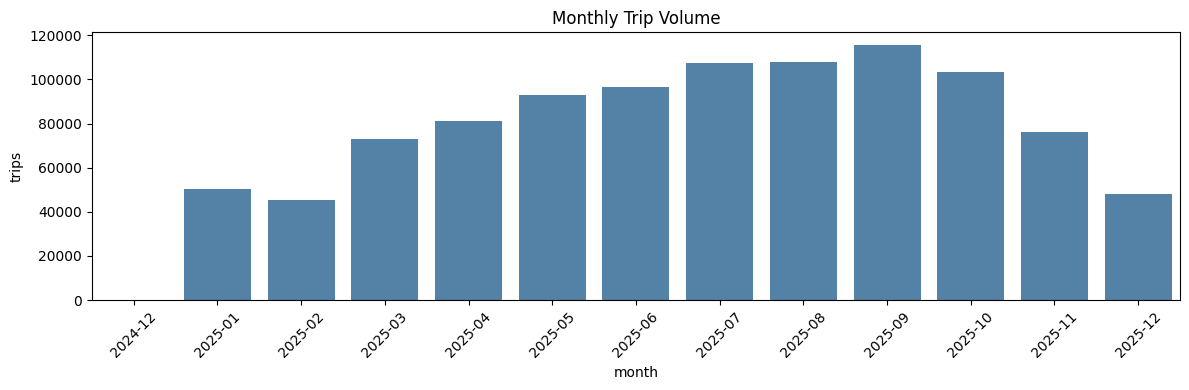

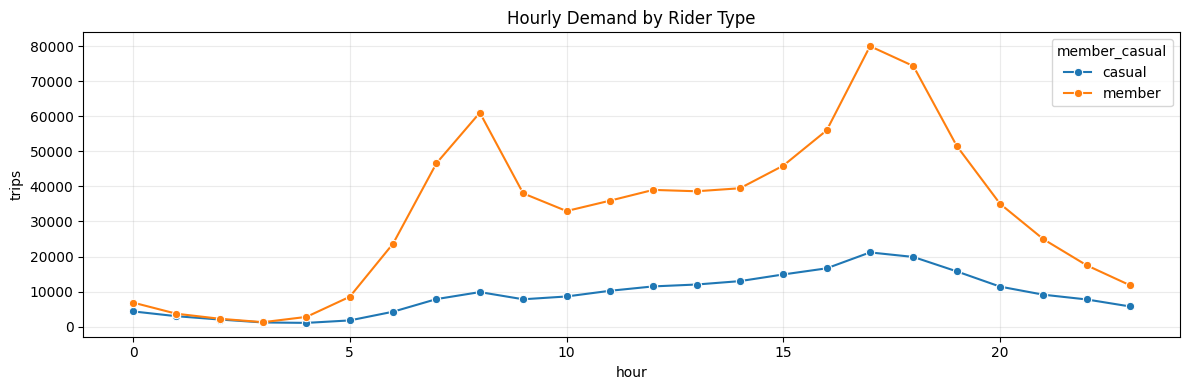

In [5]:
# Monthly trip counts
monthly_counts = (
    trips
    .assign(month=trips['datetime_hour'].dt.to_period('M').astype(str))
    .groupby('month')
    .size()
    .reset_index(name='trips')
)

plt.figure(figsize=(12, 4))
sns.barplot(data=monthly_counts, x='month', y='trips', color='steelblue')
plt.title('Monthly Trip Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Hourly rider pattern
hourly_by_type = (
    trips.groupby(['hour', 'member_casual']).size().reset_index(name='trips')
)
plt.figure(figsize=(12, 4))
sns.lineplot(data=hourly_by_type, x='hour', y='trips', hue='member_casual', marker='o')
plt.title('Hourly Demand by Rider Type')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Station-hour net demand (leakage-safe)

We compute demand at each station and each hour timestamp.

Formula:

\[
\text{net\_demand}_{s,t} = \text{inflow}_{s,t} - \text{outflow}_{s,t}
\]

where:
- \(s\) = station
- \(t\) = exact hourly timestamp (`datetime_hour`)

Critical rule: all merges must use `['station', 'datetime_hour']` (not only `['station', 'hour']`).


In [6]:
def build_hourly_station_net_demand(trips_df):
    # Outflow: bikes leaving a station at timestamp t
    outflows = (
        trips_df
        .groupby(['start_station_name', 'datetime_hour'])
        .size()
        .reset_index(name='outflow')
        .rename(columns={'start_station_name': 'station'})
    )

    # Inflow: bikes arriving at a station at timestamp t
    inflows = (
        trips_df
        .groupby(['end_station_name', 'datetime_hour'])
        .size()
        .reset_index(name='inflow')
        .rename(columns={'end_station_name': 'station'})
    )

    hourly = (
        outflows
        .merge(inflows, on=['station', 'datetime_hour'], how='outer')
        .fillna({'outflow': 0.0, 'inflow': 0.0})
    )
    hourly['net_demand'] = hourly['inflow'] - hourly['outflow']

    # Stable coordinates per station (mean over observed records)
    start_coords = trips_df[['start_station_name', 'start_lat', 'start_lng']].rename(
        columns={'start_station_name': 'station', 'start_lat': 'lat', 'start_lng': 'lng'}
    )
    end_coords = trips_df[['end_station_name', 'end_lat', 'end_lng']].rename(
        columns={'end_station_name': 'station', 'end_lat': 'lat', 'end_lng': 'lng'}
    )
    coords_lookup = (
        pd.concat([start_coords, end_coords], ignore_index=True)
        .dropna(subset=['station', 'lat', 'lng'])
        .groupby('station', as_index=False)[['lat', 'lng']]
        .mean()
    )

    hourly = hourly.merge(coords_lookup, on='station', how='left')
    hourly = hourly.sort_values(['station', 'datetime_hour']).reset_index(drop=True)

    # Key integrity check
    dup = hourly.duplicated(['station', 'datetime_hour']).sum()
    if dup != 0:
        raise ValueError(f'Duplicate station-hour keys found: {dup}')

    return hourly, coords_lookup

hourly_df, coords_lookup = build_hourly_station_net_demand(trips)
print('hourly_df shape:', hourly_df.shape)
print('Stations:', hourly_df['station'].nunique())
print('Time range:', hourly_df['datetime_hour'].min(), 'to', hourly_df['datetime_hour'].max())


hourly_df shape: (476951, 7)
Stations: 487
Time range: 2024-12-31 23:00:00 to 2025-12-31 23:00:00


## Build complete station-hour grid

For correct lag features, every station must have every hour in the timeline.
Missing rows are filled with `net_demand = 0`.


In [7]:
def build_complete_grid(hourly_df, coords_lookup):
    stations = np.sort(coords_lookup['station'].unique())
    full_hours = pd.date_range(
        hourly_df['datetime_hour'].min(),
        hourly_df['datetime_hour'].max(),
        freq='h'
    )

    grid = pd.MultiIndex.from_product(
        [stations, full_hours], names=['station', 'datetime_hour']
    ).to_frame(index=False)

    merged = grid.merge(
        hourly_df[['station', 'datetime_hour', 'net_demand']],
        on=['station', 'datetime_hour'],
        how='left'
    )
    merged['net_demand'] = merged['net_demand'].fillna(0.0).astype('float32')

    merged = merged.merge(coords_lookup, on='station', how='left')

    merged['date'] = merged['datetime_hour'].dt.normalize()
    merged['hour'] = merged['datetime_hour'].dt.hour.astype('int8')
    merged['day_of_week'] = merged['datetime_hour'].dt.dayofweek.astype('int8')
    merged['is_weekend'] = (merged['day_of_week'] >= 5).astype('int8')

    return merged

base_df = build_complete_grid(hourly_df, coords_lookup)
print('base_df shape:', base_df.shape)
print('Rows per station (example):', base_df.groupby('station').size().iloc[0])


base_df shape: (4266607, 9)
Rows per station (example): 8761


## Time encoding + lag features

Cyclical encoding:

\[
\text{hour\_sin} = \sin\left(2\pi \cdot \frac{\text{hour}}{24}\right),
\quad
\text{hour\_cos} = \cos\left(2\pi \cdot \frac{\text{hour}}{24}\right)
\]

\[
\text{day\_sin} = \sin\left(2\pi \cdot \frac{\text{day\_of\_week}}{7}\right),
\quad
\text{day\_cos} = \cos\left(2\pi \cdot \frac{\text{day\_of\_week}}{7}\right)
\]

Lag features (strictly past values per station):

\[
\text{lag}_{k}(s,t) = y_{s,t-k}
\]

Rolling mean:

\[
\text{rolling\_mean\_3h}(s,t) = \frac{1}{3}\sum_{i=1}^{3} y_{s,t-i}
\]


In [8]:
def add_time_and_lag_features(df):
    feat = df.sort_values(['station', 'datetime_hour']).copy()

    feat['hour_sin'] = np.sin(2 * np.pi * feat['hour'] / 24).astype('float32')
    feat['hour_cos'] = np.cos(2 * np.pi * feat['hour'] / 24).astype('float32')
    feat['day_sin'] = np.sin(2 * np.pi * feat['day_of_week'] / 7).astype('float32')
    feat['day_cos'] = np.cos(2 * np.pi * feat['day_of_week'] / 7).astype('float32')

    for lag in [1, 2, 3, 24]:
        feat[f'lag_{lag}h'] = (
            feat.groupby('station', sort=False)['net_demand'].shift(lag).astype('float32')
        )

    feat['rolling_mean_3h'] = (
        feat.groupby('station', sort=False)['net_demand']
        .transform(lambda s: s.shift(1).rolling(window=3).mean())
        .astype('float32')
    )

    # Remove warm-up rows without full lag context
    needed = ['lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h']
    feat = feat.dropna(subset=needed).reset_index(drop=True)

    return feat

final_df = add_time_and_lag_features(base_df)
print('final_df shape:', final_df.shape)
print(final_df[['station', 'datetime_hour', 'net_demand', 'lag_1h', 'lag_24h']].head())


final_df shape: (4254919, 18)
           station       datetime_hour  net_demand  lag_1h  lag_24h
0  1 Ave & E 38 St 2025-01-01 23:00:00         0.0     0.0      0.0
1  1 Ave & E 38 St 2025-01-02 00:00:00         0.0     0.0      0.0
2  1 Ave & E 38 St 2025-01-02 01:00:00         0.0     0.0      0.0
3  1 Ave & E 38 St 2025-01-02 02:00:00         0.0     0.0      0.0
4  1 Ave & E 38 St 2025-01-02 03:00:00         0.0     0.0      0.0


## Leakage checks (must pass before save)

These checks prevent the exact failure mode from v1.


In [9]:
def leakage_checks(df):
    # 1) Catastrophic check: lag_24h identical to target everywhere
    exact_match_ratio = float((df['net_demand'] == df['lag_24h']).mean())
    print('exact_match_ratio(net_demand == lag_24h):', round(exact_match_ratio, 6))

    # 2) MAE of lag_24h as predictor should not be exactly zero
    lag24_mae = float((df['net_demand'] - df['lag_24h']).abs().mean())
    print('lag_24h baseline MAE:', round(lag24_mae, 6))

    # 3) Across dates, each station-hour should not all be constant
    per_station_hour_nunique = (
        df.groupby(['station', 'hour'])['net_demand'].nunique()
    )
    all_constant_station_hour = bool(per_station_hour_nunique.eq(1).all())
    print('all station-hour groups constant across dates:', all_constant_station_hour)

    if exact_match_ratio >= 0.999999:
        raise ValueError('Leakage detected: lag_24h is identical to net_demand.')
    if lag24_mae <= 1e-12:
        raise ValueError('Leakage detected: lag_24h predicts target perfectly.')
    if all_constant_station_hour:
        raise ValueError('Leakage detected: station-hour demand is constant across all dates.')

leakage_checks(final_df)
print('Leakage checks passed.')


exact_match_ratio(net_demand == lag_24h): 0.886333
lag_24h baseline MAE: 0.263104
all station-hour groups constant across dates: False
Leakage checks passed.


## Save final dataset

Output columns are aligned with model-training notebooks.


In [10]:
ordered_cols = [
    'station', 'date', 'hour', 'datetime_hour', 'is_weekend',
    'net_demand', 'lat', 'lng',
    'hour_sin', 'hour_cos', 'day_of_week', 'day_sin', 'day_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h'
]

save_df = final_df[ordered_cols].copy()
save_df.to_csv(OUTPUT_FILE, index=False)

print('Saved:', OUTPUT_FILE)
print('Rows :', len(save_df))
print('Stations:', save_df['station'].nunique())
print('Date range:', save_df['datetime_hour'].min(), 'to', save_df['datetime_hour'].max())


Saved: /content/drive/My Drive/AIT/ML/citibike-netdemand-prediction/data/proceed/micro_mobility_training_data_2025_v2.csv
Rows : 4254919
Stations: 487
Date range: 2025-01-01 23:00:00 to 2025-12-31 23:00:00


## Post-save sanity checks


In [11]:
preview = pd.read_csv(OUTPUT_FILE, nrows=5)
print('Preview columns:', list(preview.columns))
display(preview)

# Quick distribution checks
summary = save_df[['net_demand', 'lag_1h', 'lag_24h', 'rolling_mean_3h']].describe().T
summary['zero_ratio'] = [
    float((save_df[c] == 0).mean()) for c in ['net_demand', 'lag_1h', 'lag_24h', 'rolling_mean_3h']
]
display(summary)

# Free some memory in Colab
_ = gc.collect()


Preview columns: ['station', 'date', 'hour', 'datetime_hour', 'is_weekend', 'net_demand', 'lat', 'lng', 'hour_sin', 'hour_cos', 'day_of_week', 'day_sin', 'day_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h']


,station,date,hour,datetime_hour,is_weekend,net_demand,lat,lng,hour_sin,hour_cos,day_of_week,day_sin,day_cos,lag_1h,lag_2h,lag_3h,lag_24h,rolling_mean_3h
0,1 Ave & E 38 St,2025-01-01,23,2025-01-01 23:00:00,0,0.0,40.746202,-73.971822,-0.258819,0.965926,2,0.974928,-0.222521,0.0,0.0,0.0,0.0,0.0
1,1 Ave & E 38 St,2025-01-02,0,2025-01-02 00:00:00,0,0.0,40.746202,-73.971822,0.000000,1.000000,3,0.433884,-0.900969,0.0,0.0,0.0,0.0,0.0
2,1 Ave & E 38 St,2025-01-02,1,2025-01-02 01:00:00,0,0.0,40.746202,-73.971822,0.258819,0.965926,3,0.433884,-0.900969,0.0,0.0,0.0,0.0,0.0
3,1 Ave & E 38 St,2025-01-02,2,2025-01-02 02:00:00,0,0.0,40.746202,-73.971822,0.500000,0.866025,3,0.433884,-0.900969,0.0,0.0,0.0,0.0,0.0
4,1 Ave & E 38 St,2025-01-02,3,2025-01-02 03:00:00,0,0.0,40.746202,-73.971822,0.707107,0.707107,3,0.433884,-0.900969,0.0,0.0,0.0,0.0,0.0


,count,mean,std,min,25%,50%,75%,max,zero_ratio
net_demand,4254919.0,0.000000e+00,0.964410,-54.000000,0.0,0.0,0.0,56.0,0.905211
lag_1h,4254919.0,0.000000e+00,0.964410,-54.000000,0.0,0.0,0.0,56.0,0.905210
lag_24h,4254919.0,0.000000e+00,0.964445,-54.000000,0.0,0.0,0.0,56.0,0.905198
rolling_mean_3h,4254919.0,-5.087854e-11,0.697046,-34.666668,0.0,0.0,0.0,37.0,0.872206


## Data Validation Proof

Run this block after saving the dataset. It performs schema, temporal integrity, feature alignment, and anti-leakage checks, then writes a JSON report for auditability.


In [12]:
import json
from pathlib import Path
import numpy as np
import pandas as pd


def validate_training_dataset(csv_path: Path):
    df = pd.read_csv(csv_path)

    if 'datetime_hour' in df.columns:
        df['datetime_hour'] = pd.to_datetime(df['datetime_hour'], errors='coerce')
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')

    results = {}
    results['rows'] = int(len(df))
    results['stations'] = int(df['station'].nunique())

    required_cols = [
        'station','date','hour','datetime_hour','is_weekend','net_demand','lat','lng',
        'hour_sin','hour_cos','day_of_week','day_sin','day_cos','lag_1h','lag_2h','lag_3h','lag_24h','rolling_mean_3h'
    ]
    results['missing_required_columns'] = [c for c in required_cols if c not in df.columns]
    results['null_counts_key'] = {c: int(df[c].isna().sum()) for c in required_cols if c in df.columns}

    results['duplicate_station_datetime_rows'] = int(df.duplicated(['station','datetime_hour']).sum())

    s = df.sort_values(['station', 'datetime_hour']).reset_index(drop=True)
    delta = s.groupby('station')['datetime_hour'].diff().dropna()
    results['time_gap_non_1h_count'] = int((delta != pd.Timedelta(hours=1)).sum())

    for lag in [1, 2, 3, 24]:
        expected = s.groupby('station')['net_demand'].shift(lag)
        col = f'lag_{lag}h'
        mask = expected.notna()
        mism = int((s.loc[mask, col].values != expected.loc[mask].values).sum())
        results[f'{col}_rows_checked'] = int(mask.sum())
        results[f'{col}_mismatch_count'] = mism
        results[f'{col}_mismatch_ratio'] = float(mism / mask.sum()) if mask.sum() else 0.0

    expected_roll = s.groupby('station')['net_demand'].transform(lambda x: x.shift(1).rolling(3).mean())
    mask_roll = expected_roll.notna()
    roll_mism = int((~np.isclose(s.loc[mask_roll, 'rolling_mean_3h'].values, expected_roll.loc[mask_roll].values, atol=1e-6)).sum())
    results['rolling_mean_3h_rows_checked'] = int(mask_roll.sum())
    results['rolling_mean_3h_mismatch_count'] = roll_mism
    results['rolling_mean_3h_mismatch_ratio'] = float(roll_mism / mask_roll.sum()) if mask_roll.sum() else 0.0

    results['net_equals_lag24_ratio'] = float((df['net_demand'] == df['lag_24h']).mean())
    results['lag24_mae_baseline'] = float((df['net_demand'] - df['lag_24h']).abs().mean())

    nunique_sh = df.groupby(['station', 'hour'])['net_demand'].nunique()
    results['station_hour_groups'] = int(len(nunique_sh))
    results['station_hour_all_constant_flag'] = bool(nunique_sh.eq(1).all())
    results['station_hour_constant_ratio'] = float(nunique_sh.eq(1).mean())
    results['station_hour_nunique_min'] = int(nunique_sh.min())
    results['station_hour_nunique_median'] = float(nunique_sh.median())
    results['station_hour_nunique_max'] = int(nunique_sh.max())

    hour_rad = 2 * np.pi * df['hour'] / 24
    day_rad = 2 * np.pi * df['day_of_week'] / 7
    results['hour_sin_abs_max_err'] = float(np.abs(df['hour_sin'] - np.sin(hour_rad)).max())
    results['hour_cos_abs_max_err'] = float(np.abs(df['hour_cos'] - np.cos(hour_rad)).max())
    results['day_sin_abs_max_err'] = float(np.abs(df['day_sin'] - np.sin(day_rad)).max())
    results['day_cos_abs_max_err'] = float(np.abs(df['day_cos'] - np.cos(day_rad)).max())

    weekend_expected = (df['day_of_week'] >= 5).astype(int)
    results['is_weekend_mismatch_count'] = int((df['is_weekend'].astype(int) != weekend_expected).sum())

    results['hour_range'] = [int(df['hour'].min()), int(df['hour'].max())]
    results['day_of_week_range'] = [int(df['day_of_week'].min()), int(df['day_of_week'].max())]

    checks = {
        'schema_complete': len(results['missing_required_columns']) == 0,
        'no_key_duplicates': results['duplicate_station_datetime_rows'] == 0,
        'hourly_continuity': results['time_gap_non_1h_count'] == 0,
        'lag_1h_exact': results['lag_1h_mismatch_count'] == 0,
        'lag_2h_exact': results['lag_2h_mismatch_count'] == 0,
        'lag_3h_exact': results['lag_3h_mismatch_count'] == 0,
        'lag_24h_exact': results['lag_24h_mismatch_count'] == 0,
        'rolling_mean_exact': results['rolling_mean_3h_mismatch_count'] == 0,
        'not_perfect_lag24_leakage': results['net_equals_lag24_ratio'] < 0.999999 and results['lag24_mae_baseline'] > 1e-12,
        'not_all_station_hour_constant': results['station_hour_all_constant_flag'] is False,
        'cyclic_features_valid': max(
            results['hour_sin_abs_max_err'],
            results['hour_cos_abs_max_err'],
            results['day_sin_abs_max_err'],
            results['day_cos_abs_max_err'],
        ) < 1e-6,
        'is_weekend_consistent': results['is_weekend_mismatch_count'] == 0,
        'hour_range_valid': results['hour_range'] == [0, 23],
        'day_range_valid': results['day_of_week_range'] == [0, 6],
    }

    results['checks'] = checks
    results['all_checks_passed'] = bool(all(checks.values()))
    return results


report = validate_training_dataset(OUTPUT_FILE)

report_dir = PROJECT_ROOT / 'artifacts' / 'data_validation'
report_dir.mkdir(parents=True, exist_ok=True)
report_path = report_dir / f"{OUTPUT_FILE.stem}_validation_report.json"
report_path.write_text(json.dumps(report, indent=2), encoding='utf-8')

print('Validation report saved:', report_path)
print('all_checks_passed:', report['all_checks_passed'])
for k, v in report['checks'].items():
    print(f'- {k}: {v}')
print('key metrics:')
print('  net_equals_lag24_ratio =', report['net_equals_lag24_ratio'])
print('  lag24_mae_baseline     =', report['lag24_mae_baseline'])
print('  station_hour_constant_ratio =', report['station_hour_constant_ratio'])


Validation report saved: /content/drive/My Drive/AIT/ML/citibike-netdemand-prediction/artifacts/data_validation/micro_mobility_training_data_2025_v2_validation_report.json
all_checks_passed: True
- schema_complete: True
- no_key_duplicates: True
- hourly_continuity: True
- lag_1h_exact: True
- lag_2h_exact: True
- lag_3h_exact: True
- lag_24h_exact: True
- rolling_mean_exact: True
- not_perfect_lag24_leakage: True
- not_all_station_hour_constant: True
- cyclic_features_valid: True
- is_weekend_consistent: True
- hour_range_valid: True
- day_range_valid: True
key metrics:
  net_equals_lag24_ratio = 0.8863332063430585
  lag24_mae_baseline     = 0.2631039509800304
  station_hour_constant_ratio = 0.6975530458590007
